<a href="https://colab.research.google.com/github/Ekliipce/Deep-Learning-Architectures-A-Learning-Journey/blob/main/objet_detection/R_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#R-CNN for object detection

In [ ]:
!pip -q install selectivesearch



In [ ]:
import selectivesearch
import torch
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import pickle



from torchvision import transforms, models, datasets
from torchvision.datasets import VOCDetection
from torchvision.ops import nms
from tqdm.notebook import tqdm

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## 1. Dataset

### a. Download dataset

In [ ]:
dataset = VOCDetection(
    root="/content/data/",
    year="2007",
    image_set="trainval",
    download=True,
    transform=transforms.ToTensor()
)

dataset

Dataset VOCDetection
    Number of datapoints: 5011
    Root location: /content/data/
    StandardTransform
Transform: ToTensor()

In [ ]:
data_dir = os.path.join("/content", "data", "VOCdevkit", "VOC2007")


for root, dirs, _ in os.walk(data_dir):
    ## print tree dir

    level = root.replace(data_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print('{}{}/'.format(indent, os.path.basename(root)))

VOC2007/
    SegmentationClass/
    ImageSets/
        Layout/
        Main/
        Segmentation/
    JPEGImages/
    SegmentationObject/
    Annotations/


In [ ]:
CLASSES = [
    'background',   # 0
    'aeroplane',    # 1
    'bicycle',      # 2
    'bird',         # 3
    'boat',         # 4
    'bottle',       # 5
    'bus',          # 6
    'car',          # 7
    'cat',          # 8
    'chair',        # 9
    'cow',          # 10
    'diningtable',  # 11
    'dog',          # 12
    'horse',        # 13
    'motorbike',    # 14
    'person',       # 15
    'pottedplant',  # 16
    'sheep',        # 17
    'sofa',         # 18
    'train',        # 19
    'tvmonitor',    # 20
]


def voc_target_to_tensor(target):
    """Convertit les annotations XML VOC en tenseurs PyTorch."""

    boxes, labels = [], []
    for obj in target['annotation']['object']:
        bb = obj['bndbox']
        boxes.append([int(bb['xmin']), int(bb['ymin']),
                      int(bb['xmax']), int(bb['ymax'])])
        labels.append(CLASSES.index(obj['name']))

    return {
        'boxes':  torch.tensor(boxes,  dtype=torch.float32),
        'labels': torch.tensor(labels, dtype=torch.int64),
    }

img, raw_target = dataset[0]
target = voc_target_to_tensor(raw_target)
print(f"Image: {img.shape} — {len(target['boxes'])} objets détectés")
print(f"Classes: {target['labels']}")
print(f"Boxes:   {target['boxes']}")

Image: torch.Size([3, 375, 500]) — 5 objets détectés
Classes: tensor([9, 9, 9, 9, 9])
Boxes:   tensor([[263., 211., 324., 339.],
        [165., 264., 253., 372.],
        [  5., 244.,  67., 374.],
        [241., 194., 295., 299.],
        [277., 186., 312., 220.]])


In [ ]:
raw_target

{'annotation': {'folder': 'VOC2007',
  'filename': '000005.jpg',
  'source': {'database': 'The VOC2007 Database',
   'annotation': 'PASCAL VOC2007',
   'image': 'flickr',
   'flickrid': '325991873'},
  'owner': {'flickrid': 'archintent louisville', 'name': '?'},
  'size': {'width': '500', 'height': '375', 'depth': '3'},
  'segmented': '0',
  'object': [{'name': 'chair',
    'pose': 'Rear',
    'truncated': '0',
    'difficult': '0',
    'bndbox': {'xmin': '263', 'ymin': '211', 'xmax': '324', 'ymax': '339'}},
   {'name': 'chair',
    'pose': 'Unspecified',
    'truncated': '0',
    'difficult': '0',
    'bndbox': {'xmin': '165', 'ymin': '264', 'xmax': '253', 'ymax': '372'}},
   {'name': 'chair',
    'pose': 'Unspecified',
    'truncated': '1',
    'difficult': '1',
    'bndbox': {'xmin': '5', 'ymin': '244', 'xmax': '67', 'ymax': '374'}},
   {'name': 'chair',
    'pose': 'Unspecified',
    'truncated': '0',
    'difficult': '0',
    'bndbox': {'xmin': '241', 'ymin': '194', 'xmax': '295',

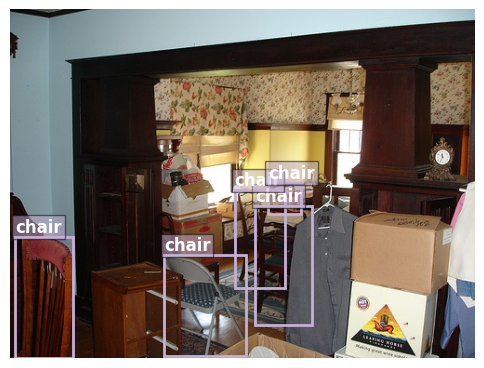

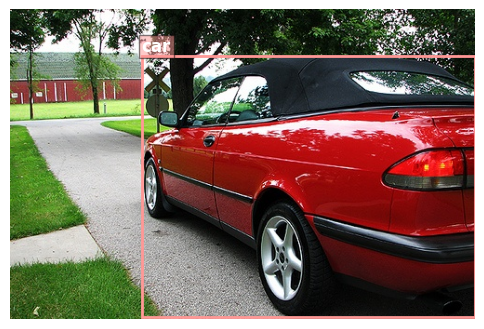

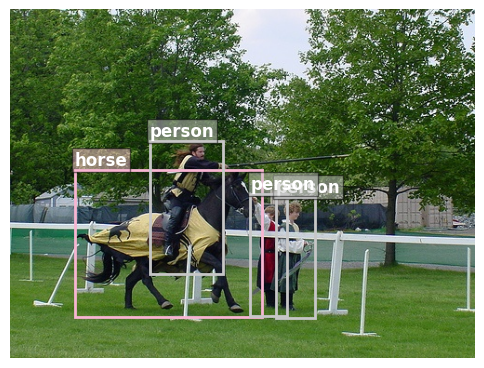

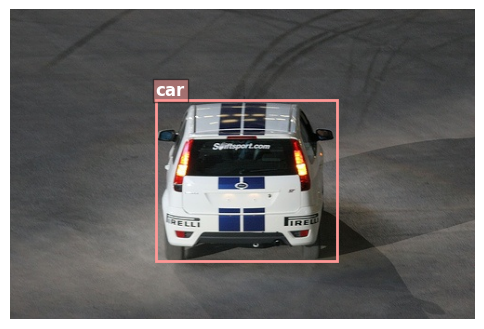

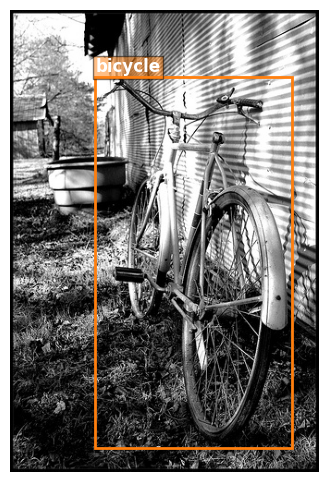

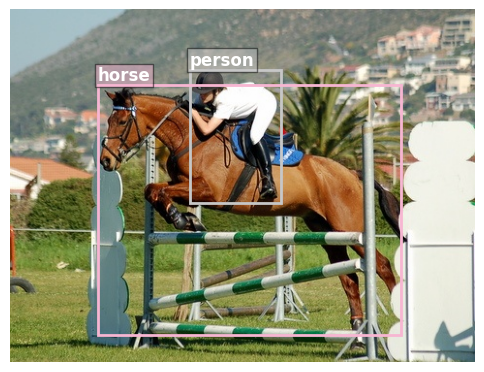

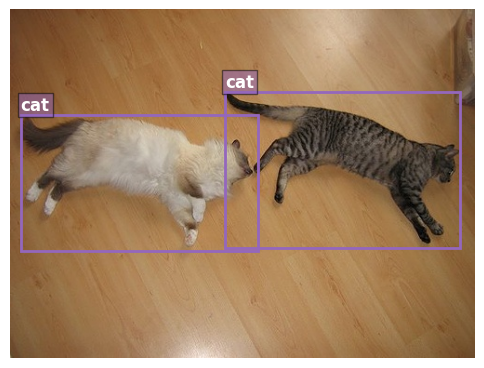

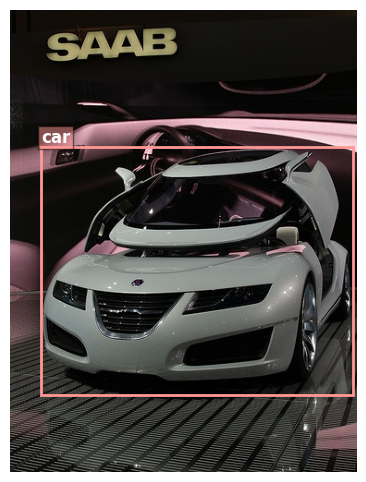

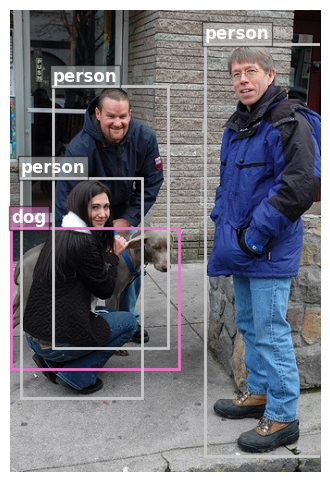

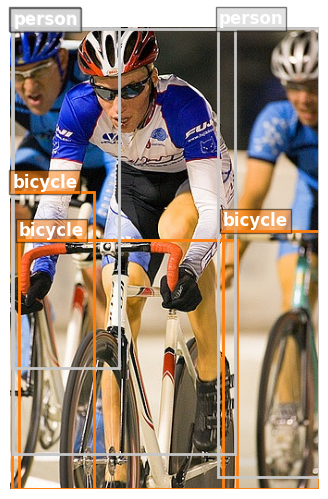

In [ ]:
def show_sample(img, boxes, labels, classes):
    if isinstance(img, torch.Tensor):
        img_np = img.permute(1, 2, 0).cpu().numpy()
    else:
        img_np = np.array(img)

    fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.imshow(img_np)

    if isinstance(boxes, torch.Tensor):
        boxes = boxes.cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()

    cmap = plt.get_cmap('tab20')

    for box, label_idx in zip(boxes, labels):
        xmin, ymin, xmax, ymax = box
        width = xmax - xmin
        height = ymax - ymin

        class_name = classes[label_idx]
        color = cmap(label_idx % 20)

        rect = patches.Rectangle(
            (xmin, ymin), width, height,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)

        ax.text(
            xmin, ymin - 5, class_name,
            bbox=dict(facecolor=color, alpha=0.5, pad=2),
            fontsize=12, color='white', weight='bold'
        )

    plt.axis('off')
    plt.show()


for i in range(10):
    img, raw_target = dataset[i]
    target = voc_target_to_tensor(raw_target)
    show_sample(img, target['boxes'], target['labels'], CLASSES)

### b. Create dataframe

In [ ]:
columns = [
    "path",
    "label_name",
    "xmin",
    "xmax",
    "ymin",
    "ymax",
    "confidence",
]

data = []
for i in tqdm(range(len(dataset))):
    img, raw_target = dataset[i]
    path = os.path.join(data_dir, "JPEGImages", raw_target["annotation"]["filename"]),
    for obj in raw_target["annotation"]["object"]:
        xmin = int(obj["bndbox"]["xmin"])
        xmax = int(obj["bndbox"]["xmax"])
        ymin = int(obj["bndbox"]["ymin"])
        ymax = int(obj["bndbox"]["ymax"])
        label_name = obj["name"]
        confidence = 1.0

        info = [
            path,
            label_name,
            xmin,
            xmax,
            ymin,
            ymax,
            confidence,
        ]
        data.append(info)

df = pd.DataFrame(data, columns=columns)
df.head(10)

  0%|          | 0/5011 [00:00<?, ?it/s]

,path,label_name,xmin,xmax,ymin,ymax,confidence
0,(/content/data/VOCdevkit/VOC2007/JPEGImages/00...,chair,263,324,211,339,1.0
1,(/content/data/VOCdevkit/VOC2007/JPEGImages/00...,chair,165,253,264,372,1.0
2,(/content/data/VOCdevkit/VOC2007/JPEGImages/00...,chair,5,67,244,374,1.0
3,(/content/data/VOCdevkit/VOC2007/JPEGImages/00...,chair,241,295,194,299,1.0
4,(/content/data/VOCdevkit/VOC2007/JPEGImages/00...,chair,277,312,186,220,1.0
5,(/content/data/VOCdevkit/VOC2007/JPEGImages/00...,car,141,500,50,330,1.0
6,(/content/data/VOCdevkit/VOC2007/JPEGImages/00...,horse,69,270,172,330,1.0
7,(/content/data/VOCdevkit/VOC2007/JPEGImages/00...,person,150,229,141,284,1.0
8,(/content/data/VOCdevkit/VOC2007/JPEGImages/00...,person,285,327,201,331,1.0
9,(/content/data/VOCdevkit/VOC2007/JPEGImages/00...,person,258,297,198,329,1.0


In [ ]:
def extract_candidates(img, min_ratio=0.05, max_ratio=1.0):
    candidates = []
    seen = set()
    _, regions = selectivesearch.selective_search(img, scale=500, min_size=100)

    img_area = np.prod(img.shape[:2])
    for r in regions:
        rect = r['rect']
        if rect in seen: continue
        if r['size'] < min_ratio * img_area: continue
        if r['size'] > max_ratio * img_area: continue

        x, y, w, h = rect
        candidates.append((x, y, x + w, y + h))   # ← conversion manquante, maintenant ajoutée
        seen.add(rect)

    return candidates

def extract_iou(boxA, boxB, epsilon=1e-5):
    x1 = np.max(boxA[0], boxB[0])
    y1 = np.max(boxA[1], boxB[1])
    x2 = np.min(boxA[2], boxB[2])
    y2 = np.min(boxA[3], boxB[3])

    W = (x2 - x1)
    H = (y2 - y1)

    if (W < 0) or (H < 0):
        return 0

    intersection = W * H
    boxA_area = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxB_area = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = boxA_area + boxB_area - intersection
    iou = intersection / (union + epsilon)

    return iou

def extract_iou_matrix(candidates, gt_boxes):
    """
    candidates : (N, 4) array (x1,y1,x2,y2)
    gt_boxes   : (M, 4) array (x1,y1,x2,y2)
    Retourne   : (N, M) matrice IoU — entièrement vectorisée
    """
    x1 = np.maximum(candidates[:, None, 0], gt_boxes[None, :, 0])
    y1 = np.maximum(candidates[:, None, 1], gt_boxes[None, :, 1])
    x2 = np.minimum(candidates[:, None, 2], gt_boxes[None, :, 2])
    y2 = np.minimum(candidates[:, None, 3], gt_boxes[None, :, 3])

    intersection = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)

    area_c = ((candidates[:, 2] - candidates[:, 0]) *
              (candidates[:, 3] - candidates[:, 1]))[:, None]
    area_g = ((gt_boxes[:, 2] - gt_boxes[:, 0]) *
              (gt_boxes[:, 3] - gt_boxes[:, 1]))[None, :]

    union = area_c + area_g - intersection
    return intersection / np.clip(union, 1e-9, None)

In [ ]:
import cv2
import warnings

def extract_candidate_infos(best_iou, best_at, candidate, gt_arr, norm, labels, fpath):
    if best_iou >= 0.3:
        label_id = int(labels[best_at])
        delta    = (gt_arr[best_at] - candidate) / norm
        gt_box   = gt_arr[best_at] / norm   # ← GT normalisée pour évaluation
    else:
        label_id = 0
        delta    = np.zeros(4, dtype=np.float32)
        gt_box   = np.zeros(4, dtype=np.float32)

    return {
        'fpath':  fpath,
        'roi':    (candidate / norm).tolist(),
        'delta':  delta.tolist(),
        'label':  label_id,
        'iou':    float(best_iou),
        'gt_box': gt_box.tolist(),   # ← pour eval mAP
    }

def extract_selective_search(img):
    """Fallback avec la lib Python si cv2.ximgproc.segmentation indisponible."""
    _, regions = selectivesearch.selective_search(img, scale=200, min_size=100)
    return [(r['rect'][0], r['rect'][1], r['rect'][2], r['rect'][3])
            for r in regions]

def process_one_image(args):
    fpath, gt_boxes, labels = args

    img = cv2.imread(fpath)
    if img is None:
        return []
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.uint8)
    H, W, _ = img.shape
    norm    = np.array([W, H, W, H], dtype=np.float32)

    # Un seul appel, format final déjà (x1,y1,x2,y2)
    candidates = extract_candidates(img)
    if len(candidates) == 0:
        return []

    candidates = np.array(candidates, dtype=np.float32)
    gt_arr     = np.array(gt_boxes,   dtype=np.float32)

    ious     = extract_iou_matrix(candidates, gt_arr)
    best_at  = ious.argmax(axis=1)
    best_iou = ious.max(axis=1)

    rows = []
    for j in range(len(candidates)):
        infos = extract_candidate_infos(
            best_iou[j], best_at[j], candidates[j],
            gt_arr, norm, labels, fpath,
        )
        rows.append(infos)
    return rows


In [12]:
from multiprocessing import Pool

label2target = {name: i for i, name in enumerate(CLASSES)}
target2label = {i: name for i, name in enumerate(CLASSES)}

def build_dataframe(ds, N=5000, n_workers=4):
    samples = []
    for ix, (img, raw_target) in enumerate(tqdm(ds, total=N)):
        if ix == N: break
        annotation = voc_target_to_tensor(raw_target)
        fpath = os.path.join(
            data_dir, "JPEGImages",
            raw_target["annotation"]["filename"]
        )
        samples.append((
            fpath,
            annotation['boxes'].tolist(),
            annotation['labels'],
        ))

    rows = []
    with Pool(n_workers) as pool:
        for image_rows in tqdm(
            pool.imap(process_one_image, samples, chunksize=4),
            total=len(samples),
            desc="Selective Search"
        ):
            rows.extend(image_rows)

    df = pd.DataFrame(rows)
    return df, label2target

df_rg, label2target = build_dataframe(dataset, N=5000, n_workers=8)
df_rg.to_pickle('rcnn_dataset.pkl')
with open('label2target.pkl', 'wb') as f:
    pickle.dump(label2target, f)

df_rg.head(10)

  0%|          | 0/5000 [00:00<?, ?it/s]

Selective Search:   0%|          | 0/5000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3

,fpath,roi,delta,label,iou,gt_box
0,/content/data/VOCdevkit/VOC2007/JPEGImages/000...,"[0.0860000029206276, 0.0, 0.9980000257492065, ...","[0.0, 0.0, 0.0, 0.0]",0,0.028833,"[0.0, 0.0, 0.0, 0.0]"
1,/content/data/VOCdevkit/VOC2007/JPEGImages/000...,"[0.13600000739097595, 0.03733333200216293, 0.9...","[0.0, 0.0, 0.0, 0.0]",0,0.054281,"[0.0, 0.0, 0.0, 0.0]"
2,/content/data/VOCdevkit/VOC2007/JPEGImages/000...,"[0.3100000023841858, 0.20266667008399963, 0.52...","[0.0, 0.0, 0.0, 0.0]",0,0.017787,"[0.0, 0.0, 0.0, 0.0]"
3,/content/data/VOCdevkit/VOC2007/JPEGImages/000...,"[0.10999999940395355, 0.7120000123977661, 0.37...","[0.0, 0.0, 0.0, 0.0]",0,0.108359,"[0.0, 0.0, 0.0, 0.0]"
4,/content/data/VOCdevkit/VOC2007/JPEGImages/000...,"[0.10999999940395355, 0.7120000123977661, 0.44...","[0.0, 0.0, 0.0, 0.0]",0,0.284712,"[0.0, 0.0, 0.0, 0.0]"
5,/content/data/VOCdevkit/VOC2007/JPEGImages/000...,"[0.3100000023841858, 0.20266667008399963, 0.52...","[0.0, 0.0, 0.0, 0.0]",0,0.035055,"[0.0, 0.0, 0.0, 0.0]"
6,/content/data/VOCdevkit/VOC2007/JPEGImages/000...,"[0.3140000104904175, 0.15466666221618652, 0.75...","[0.0, 0.0, 0.0, 0.0]",0,0.002325,"[0.0, 0.0, 0.0, 0.0]"
7,/content/data/VOCdevkit/VOC2007/JPEGImages/000...,"[0.3100000023841858, 0.15466666221618652, 0.75...","[0.0, 0.0, 0.0, 0.0]",0,0.043627,"[0.0, 0.0, 0.0, 0.0]"
8,/content/data/VOCdevkit/VOC2007/JPEGImages/000...,"[0.3100000023841858, 0.15466666221618652, 0.75...","[0.0, 0.0, 0.0, 0.0]",0,0.064082,"[0.0, 0.0, 0.0, 0.0]"
9,/content/data/VOCdevkit/VOC2007/JPEGImages/000...,"[0.3100000023841858, 0.15466666221618652, 0.75...","[0.0, 0.0, 0.0, 0.0]",0,0.101613,"[0.0, 0.0, 0.0, 0.0]"


### c. Create Dataloaders

In [13]:
from torch.utils.data import Dataset, DataLoader

class RCNNDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── Image → crop warpé
        img = cv2.imread(row['fpath'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W, _ = img.shape

        x1, y1, x2, y2 = (np.array(row['roi']) * [W, H, W, H]).astype(int)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)
        crop = img[y1:y2, x1:x2]
        if crop.size == 0:
            crop = np.zeros((224, 224, 3), dtype=np.uint8)
        crop = cv2.resize(crop, (224, 224))
        crop = torch.tensor(crop / 255.0, dtype=torch.float32).permute(2, 0, 1)
        crop = self.normalize(crop)

        # ── Targets entraînement
        label = torch.tensor(row['label'], dtype=torch.long)
        delta = torch.tensor(row['delta'], dtype=torch.float32)

        # ── Nécessaire pour inférence et évaluation
        roi    = torch.tensor(row['roi'],    dtype=torch.float32)
        gt_box = torch.tensor(row['gt_box'], dtype=torch.float32)

        return {
            'crop':  crop,
            'label': label,
            'delta': delta,
            'roi':   roi,
            'gt_box': gt_box,
        }



In [14]:
from torch.utils.data import WeightedRandomSampler

df_train = df_rg.sample(frac=0.8, random_state=42)
df_test  = df_rg.drop(df_train.index)

train_ds = RCNNDataset(df_train)
val_ds = RCNNDataset(df_test)

class_counts = df_train['label'].value_counts()
weights = df_train['label'].apply(lambda x: 1.0 / class_counts[x]).values
sampler = WeightedRandomSampler(
    weights=torch.tensor(weights, dtype=torch.float32),
    num_samples=len(df_train),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=32,
                          sampler=sampler,
                          num_workers=2,
                          pin_memory=True)

val_loader = DataLoader(val_ds, batch_size=32,
                        shuffle=False,
                        num_workers=2,
                        pin_memory=True)


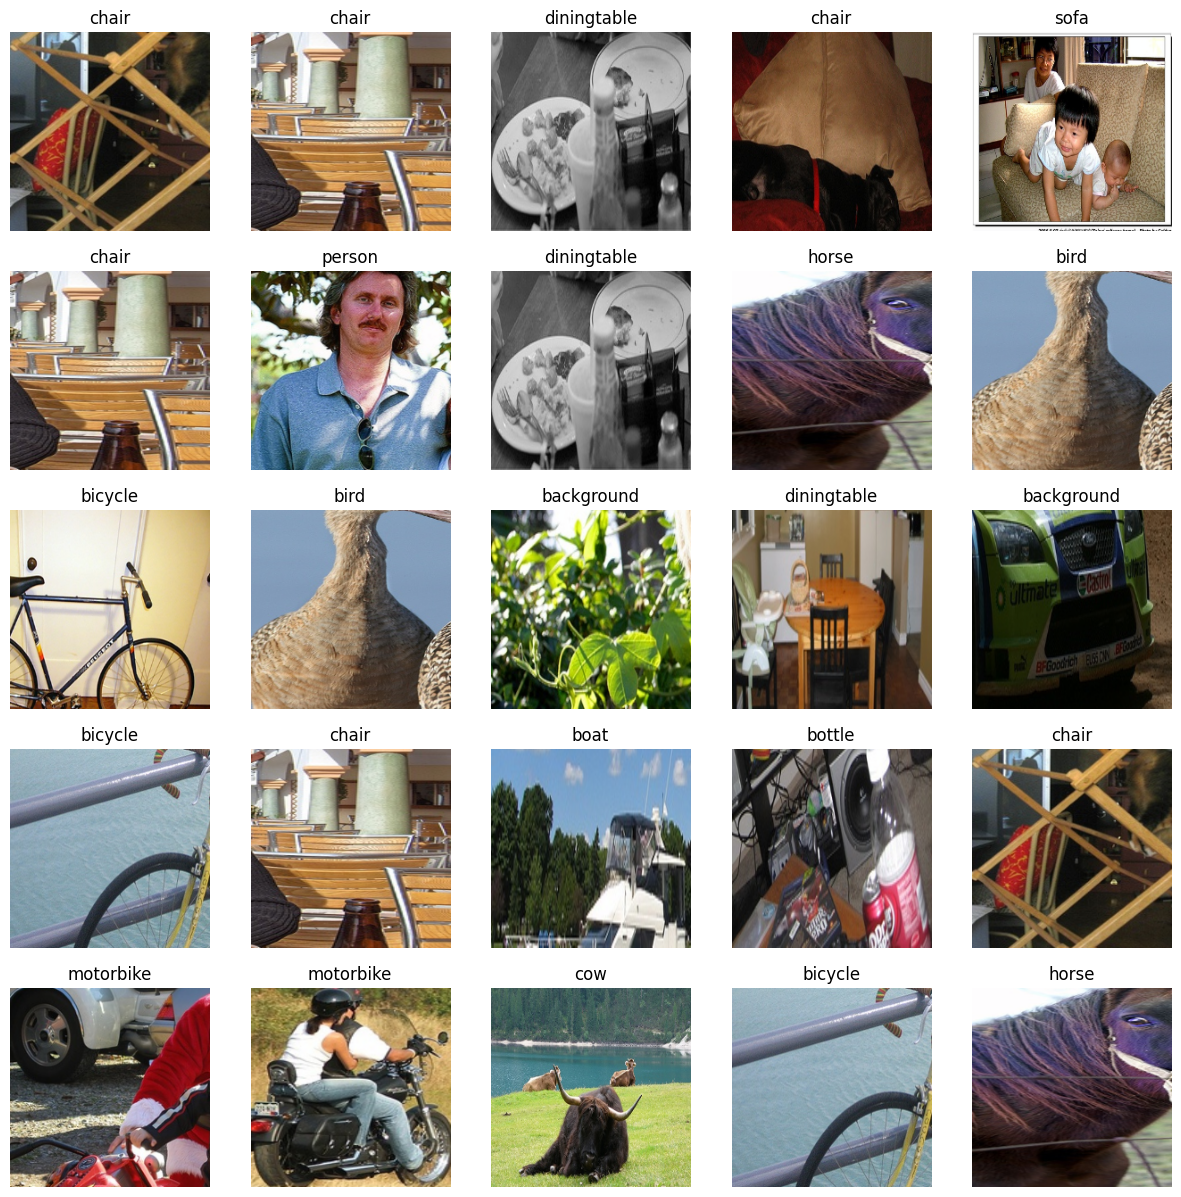

In [15]:
def show_batch(batch, rows=5, cols=5):
    crops = batch["crop"]
    labels = batch["label"]
    deltas = batch["delta"]

    figure = plt.figure(figsize=(rows*3, cols*3))
    cols, rows = cols, rows

    for i in range(1, cols * rows + 1):
        sample_idx = torch.randint(len(crops), size=(1,)).item()
        crop = crops[sample_idx]
        label = labels[sample_idx]

        crop = crop.permute(1, 2, 0).numpy()
        # denormalize
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        crop = std * crop + mean
        label = target2label[label.item()]

        figure.add_subplot(rows, cols, i)
        plt.title(label)
        plt.axis("off")
        plt.imshow(crop)

    plt.show()
    plt.close()

sample = next(iter(train_loader))
show_batch(sample)

## Model

In [16]:
import torch.nn as nn
from torchvision.models import resnet50

import torch.nn as nn
from torchvision.models import resnet50

class RCNN(nn.Module):
    def __init__(self, num_classes):
        super(RCNN, self).__init__()

        # ── Backbone ResNet50 — retire la tête de classification
        self.backbone = resnet50(pretrained=True)
        self.backbone.fc = nn.Identity()   # → sortie 2048-dim

        # ── Freeze le backbone
        for param in self.backbone.parameters():
            param.requires_grad = False

        # ── Tête classification
        self.cls_head = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

        # ── Tête régression bbox
        self.bbox_head = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 4),
        )

    def forward(self, crops):
        features   = self.backbone(crops)
        cls_logits = self.cls_head(features)
        bbox_preds = self.bbox_head(features)
        return cls_logits, bbox_preds




rccn_model = RCNN(num_classes=len(CLASSES))
rccn_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


RCNN(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0

## Train

In [17]:
class RCNNLoss(nn.Module):
    def __init__(self, lambda_loss=1):
        super(RCNNLoss, self).__init__()
        self.cls_loss  = nn.CrossEntropyLoss()
        self.bbox_loss = nn.SmoothL1Loss()
        self.lam = lambda_loss

    def forward(self, cls_logits, bbox_preds, labels, deltas):
        loss_cls = self.cls_loss(cls_logits, labels)

        bbox_mask = labels > 0
        if bbox_mask.sum() == 0:
            loss_bbox = torch.tensor(0.0, device=cls_logits.device)
        else:
            loss_bbox = self.bbox_loss(bbox_preds[bbox_mask], deltas[bbox_mask])

        return loss_cls + self.lam * loss_bbox

In [18]:
num_epochs = 5
lr = 1e-3
optimizer = torch.optim.Adam(rccn_model.parameters(), lr=lr)
criterion = RCNNLoss()

def train_one_batch(crops, labels, deltas):
    optimizer.zero_grad()
    cls_logits, bbox_preds = rccn_model(crops)
    loss = criterion(cls_logits, bbox_preds, labels, deltas)
    loss.backward()
    optimizer.step()

    return loss.item()

@torch.no_grad()
def evaluate_one_batch(crops, labels, deltas):
    cls_logits, bbox_preds = rccn_model(crops)
    loss = criterion(cls_logits, bbox_preds, labels, deltas)

    return loss.item()

train_losses = []
validation_losses = []

for epoch in tqdm(range(num_epochs)):
    batch_loss = []
    for idx, batch in enumerate(train_loader):
        crops = batch["crop"].to(device)
        labels = batch["label"].to(device)
        deltas = batch["delta"].to(device)

        loss = train_one_batch(crops, labels, deltas)
        batch_loss.append(loss)

    train_losses.append(np.mean(batch_loss))

    val_batch_loss = []
    for idx, batch in enumerate(val_loader):
        crops  = batch["crop"].to(device)
        labels = batch["label"].to(device)
        deltas = batch["delta"].to(device)
        loss_validation = evaluate_one_batch(crops, labels, deltas)
        val_batch_loss.append(loss_validation)
    validation_losses.append(np.mean(val_batch_loss))

    print(f"Epoch {epoch+1}/{num_epochs} " \
          f"Train Loss: {train_losses[-1]:.4f} " \
          f"Validation Loss: {validation_losses[-1]:.4f} ")



  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 Train Loss: 0.8290 Validation Loss: 1.9732 
Epoch 2/5 Train Loss: 0.6646 Validation Loss: 1.9752 
Epoch 3/5 Train Loss: 0.6236 Validation Loss: 1.9768 
Epoch 4/5 Train Loss: 0.6016 Validation Loss: 1.9670 
Epoch 5/5 Train Loss: 0.5748 Validation Loss: 2.1091 


In [19]:
val_batch = next(iter(val_loader))
